# Neural Networks — PyTorch Introduction

**Learning Objectives:**
- Understand PyTorch tensors and how they relate to NumPy arrays
- Move tensors between CPU and GPU devices
- Use `autograd` for automatic differentiation
- Build and inspect a `nn.Linear` layer
- Train a simple linear model on synthetic data

In [1]:
print("OIJ")

OIJ


If not installed: `pip install torch` (CPU version).

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## Part 1: PyTorch vs NumPy

PyTorch tensors behave like NumPy arrays but with GPU support and autograd.

In [3]:
# Create from list
t = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f'Tensor from list:\n{t}\n')


Tensor from list:
tensor([[1., 2.],
        [3., 4.]])



In [4]:

# Create from NumPy
a = np.array([[1.0, 2.0], [3.0, 4.0]])
t2 = torch.from_numpy(a)
print(f'Tensor from NumPy:\n{t2}\n')

# Shape, dtype, device
print(f'Shape: {t.shape}, dtype: {t.dtype}, device: {t.device}')

Tensor from NumPy:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

Shape: torch.Size([2, 2]), dtype: torch.float32, device: cpu


In [5]:
# Operations (same API as NumPy)
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

print(f'x + y = {x + y}')
print(f'x * y = {x * y}')
print(f'sin(x) = {torch.sin(x)}')
print(f'matmul: {x @ y}')

x + y = tensor([5., 7., 9.])
x * y = tensor([ 4., 10., 18.])
sin(x) = tensor([0.8415, 0.9093, 0.1411])
matmul: 32.0


In [6]:
# Special tensors
print(f'Zeros:\n{torch.zeros(2, 3)}\n')
print(f'Ones:\n{torch.ones(2, 3)}\n')
print(f'Rand:\n{torch.rand(2, 3)}\n')
print(f'Arange: {torch.arange(6).reshape(2, 3)}')

Zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones:
tensor([[1., 1., 1.],
        [1., 1., 1.]])

Rand:
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])

Arange: tensor([[0, 1, 2],
        [3, 4, 5]])


## Part 2: Devices

Tensors can live on CPU or GPU (CUDA / MPS). Operations only work on tensors on the same device.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [8]:
t_cpu = torch.tensor([1.0, 2.0, 3.0])
print(f'CPU tensor: {t_cpu.device}')

t_gpu = t_cpu.to(device)
print(f'Moved to:   {t_gpu.device}')

# Back to CPU
t_back = t_gpu.cpu()
print(f'Back to CPU: {t_back.device}')

CPU tensor: cpu
Moved to:   cpu
Back to CPU: cpu


## Part 3: Autograd

`requires_grad=True` tells PyTorch to track operations on a tensor for automatic differentiation. Call `.backward()` to compute gradients.

In [9]:
# Create a tensor with gradient tracking
x = torch.tensor([2.0], requires_grad=True)
print(f'x = {x}')

# Build a computation graph: y = x^2 + 3x + 1
y = x**2 + 3*x + 1
print(f'y = {y}')

# Backward: compute dy/dx
y.backward()
print(f'dy/dx = {x.grad}')  # should be 2*x + 3 = 7

x = tensor([2.], requires_grad=True)
y = tensor([11.], grad_fn=<AddBackward0>)
dy/dx = tensor([7.])


In [10]:
# Gradients accumulate — must zero them
x.grad.zero_()

# Multiple operations
z = torch.sin(x) + x**3
z.backward()
print(f'dz/dx = {x.grad}')  # cos(x) + 3*x^2

dz/dx = tensor([11.5839])


## Part 4: nn.Linear

A `Linear` layer applies $y = xW^T + b$. Its `.weight` and `.bias` are parameters with `requires_grad=True` by default.

In [11]:
# Linear(1, 1): 1 input feature, 1 output feature
layer = nn.Linear(1, 1)
print(f'Weight: {layer.weight.data}')
print(f'Bias:   {layer.bias.data}')
print(f'Params require_grad: weight={layer.weight.requires_grad}, bias={layer.bias.requires_grad}')

Weight: tensor([[-0.4869]])
Bias:   tensor([0.5873])
Params require_grad: weight=True, bias=True


In [12]:
# Forward pass: layer expects shape (batch, features)
x_input = torch.tensor([[2.0]])
output = layer(x_input)
print(f'Input: {x_input}')
print(f'Output: {output}')  # = x * weight + bias

Input: tensor([[2.]])
Output: tensor([[-0.3864]], grad_fn=<AddmmBackward0>)


## Part 5: Train a Linear Model on Synthetic Data

Generate data $y = 3x + 5 + \text{noise}$, then train `nn.Linear(1, 1)` to recover the slope and intercept.

In [13]:
import sys
print(f'Python version: {sys.version}')

Python version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]


In [14]:
# Generate synthetic data
true_w, true_b = 3.0, 5.0
X_np = np.random.randn(100, 1).astype(np.float32)
y_np = (true_w * X_np + true_b + 0.3 * np.random.randn(100, 1)).astype(np.float32)

X_t = torch.from_numpy(X_np)
y_t = torch.from_numpy(y_np)

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

losses = []
for epoch in range(200):
    optimizer.zero_grad()
    y_pred = model(X_t)
    loss = criterion(y_pred, y_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f'Learned: weight={model.weight.data.item():.3f}, bias={model.bias.data.item():.3f}')
print(f'True:    weight={true_w}, bias={true_b}')

Learned: weight=2.814, bias=4.867
True:    weight=3.0, bias=5.0


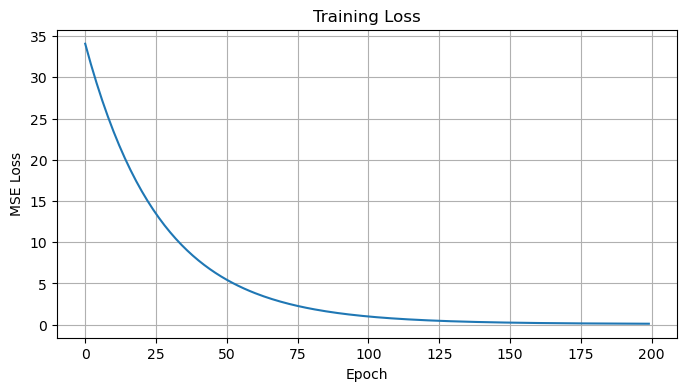

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

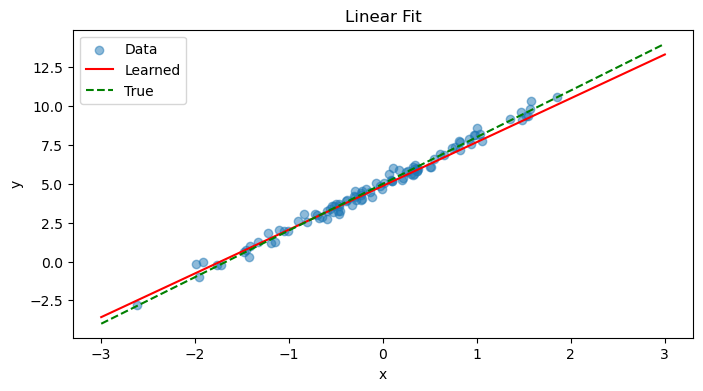

In [16]:
with torch.no_grad():
    X_plot = np.linspace(-3, 3, 100).reshape(-1, 1).astype(np.float32)
    y_plot = model(torch.from_numpy(X_plot)).numpy()

plt.figure(figsize=(8, 4))
plt.scatter(X_np, y_np, alpha=0.5, label='Data')
plt.plot(X_plot, y_plot, 'r-', label='Learned')
plt.plot(X_plot, true_w * X_plot + true_b, 'g--', label='True')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Fit')
plt.show()

### Parameter Notes — PyTorch essentials

| Concept | Key API | Description |
|---------|---------|-------------|
| Tensor creation | `torch.tensor()`, `torch.zeros()`, `torch.ones()`, `torch.rand()`, `torch.arange()` | Create tensors from data or shapes |
| From NumPy | `torch.from_numpy()` | Convert NumPy array to tensor (shares memory) |
| To NumPy | `.numpy()` | Convert tensor to NumPy array |
| Device | `.to(device)`, `.cpu()`, `.cuda()` | Move tensors between CPU/GPU |
| Autograd | `requires_grad=True`, `.backward()`, `.grad` | Automatic differentiation |
| Zero grad | `.grad.zero_()` | Clear accumulated gradients |
| No grad | `torch.no_grad()` | Context manager for inference (no graph building) |
| Linear layer | `nn.Linear(in_features, out_features)` | Fully connected layer $y = xW^T + b$ |
| Loss | `nn.MSELoss()`, `nn.CrossEntropyLoss()` | Common loss functions |
| Optimizer | `torch.optim.SGD()`, `torch.optim.Adam()` | Gradient-based optimizers |
| Training loop | `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()` | Standard PyTorch training step |

## Exercises

1. Create a 2×3 tensor of ones, move it to your device, multiply by 5, and bring it back to CPU.
2. Compute the gradient of $y = x^3 + 2x$ at $x = 3$ using autograd.
3. Create an `nn.Linear(2, 1)` layer, pass a batch of 4 samples (2 features each), and do one forward + backward pass.

In [ ]:
# TODO: Complete the exercises